# 03 — Train Emulators (Multi-z): Cluster Profiles

All cluster profile statistics: CGD, CGED, CPP, CTP, CEP, CEEP, CMP, CYP.
Multi-snapshot emulators (z ≤ 0.5, snapshots 415–624).
All models saved to `../models/<PROFILE>_multiz/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib.cm as cm
import os

from cosmo_hydro_emu.pca import *
from cosmo_hydro_emu.viz import *
from cosmo_hydro_emu.load_hacc import *
from cosmo_hydro_emu.emu import *
from cosmo_hydro_emu.gp import *
from cosmo_hydro_emu.snapshot_utils import SNAPSHOT_IDS, get_snapshot_redshifts

## Configuration

In [ ]:
DirIn = '../data/400MPC_RUNS_5SG_2COSMO_PARAM/HAvoCC/'

start_sim_idx = 1
num_sims = 39
# 0.95 is the canonical value used by every Inference YAML config; the saved
# basis size (pu) must match what Inference rebuilds at load time, otherwise
# emulate() reshapes will fail.
exp_variance = 0.95

z_initial = 200

do_train = True

seed_mass_scale = 1e6
vkin_scale = 1e4
eps_scale = 1e1

## Load parameters

In [3]:
fileIn = '../data/FinalDesign.txt'
params_all = np.loadtxt(fileIn, delimiter=",", skiprows=1)
# Design CSV row K corresponds to RUN_K (both 0-indexed); row 0 = RUN000.
# With start_sim_idx=1, num_sims=39 the loaders read RUN001..RUN039; the
# matching slice is rows [1:40] = [start_sim_idx : start_sim_idx + num_sims].
params32 = params_all[start_sim_idx : start_sim_idx + num_sims]
params32[:, 2] /= seed_mass_scale
params32[:, 3] /= vkin_scale
params32[:, 4] /= eps_scale

print('params32 shape:', params32.shape)

# Train/test split
test_sim_indices = np.array([3, 11, 19, 27, 35])
train_sim_indices = np.array([i for i in range(num_sims) if i not in test_sim_indices])

params_train = params32[train_sim_indices]
params_test = params32[test_sim_indices]

print(f'Train: {len(train_sim_indices)} sims, Test: {len(test_sim_indices)} sims')

params32 shape: (39, 7)
Train: 34 sims, Test: 5 sims


## Snapshot setup

In [4]:
z_all, a_all = get_snapshot_redshifts(SNAPSHOT_IDS, z_initial=z_initial)

print(f'Number of snapshots: {len(SNAPSHOT_IDS)}')
print(f'Snapshot IDs: {SNAPSHOT_IDS}')
print(f'Redshift range: z = {z_all[-1]:.2f} to {z_all[0]:.2f}')
print(f'Scale factor range: a = {a_all[0]:.3f} to {a_all[-1]:.3f}')

Number of snapshots: 11
Snapshot IDs: [205, 224, 247, 275, 310, 355, 415, 479, 498, 567, 624]
Redshift range: z = 0.00 to 2.00
Scale factor range: a = 0.333 to 1.000


## Load all profile data

In [5]:
from cosmo_hydro_emu.load_hacc import read_profile_all_snaps

PROFILE_CONFIGS = {
    'CGD':  {'file_prefix': 'ClusterGasDensityProfile',         'label': 'Cluster Gas Density'},
    'CGED': {'file_prefix': 'ClusterGasElectronDensityProfile',  'label': 'Cluster Gas Electron Density'},
    'CPP':  {'file_prefix': 'ClusterGasPressureProfile',         'label': 'Cluster Gas Pressure'},
    'CTP':  {'file_prefix': 'ClusterGasTemperatureProfile',      'label': 'Cluster Gas Temperature'},
    'CEP':  {'file_prefix': 'ClusterGasEntropyProfile',          'label': 'Cluster Gas Entropy'},
    'CEEP': {'file_prefix': 'ClusterElectronEntropyProfile',     'label': 'Cluster Electron Entropy'},
    'CMP':  {'file_prefix': 'ClusterGasMetallicityProfile',      'label': 'Cluster Gas Metallicity'},
    'CYP':  {'file_prefix': 'ClusterGasYProfile',                'label': 'Cluster Compton-y (tSZ)'},
}

profile_data = {}
for short_name, config in PROFILE_CONFIGS.items():
    radius, arr = read_profile_all_snaps(DirIn, num_sims, SNAPSHOT_IDS,
                                          config['file_prefix'],
                                          start_sim_idx=start_sim_idx)
    profile_data[short_name] = arr
    print(f"{short_name}: {arr.shape}")

print(f"Radius bins: {radius.shape}")

CGD: (39, 11, 19)
CGED: (39, 11, 19)
CPP: (39, 11, 19)
CTP: (39, 11, 19)
CEP: (39, 11, 19)
CEEP: (39, 11, 19)
CMP: (39, 11, 19)
CYP: (39, 11, 19)
Radius bins: (19,)


## Radius cut

In [6]:
rlim1, rlim2 = mass_conds('CGD')  # same limits for all profiles
rad_cond = np.where((radius > rlim1) & (radius < rlim2))[0]
y_ind_profiles = radius[rad_cond]
print(f"Radius cut: {len(rad_cond)} bins in [{rlim1:.3f}, {rlim2:.3f}]")

Radius cut: 19 bins in [0.015, 2.750]


## Train all profiles

In [7]:
profile_z_start_idx = 6  # z <= 0.5
z_index_range = np.arange(profile_z_start_idx, len(SNAPSHOT_IDS))
profile_z_all = z_all[profile_z_start_idx:]

profile_models = {}

for short_name, config in PROFILE_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Training {short_name}: {config['label']}")
    print(f"{'='*60}")

    arr = profile_data[short_name]
    y_vals = arr[:, :, rad_cond]  # (num_sims, num_snaps, n_bins_cut)

    model_dir = f'../models/{short_name}_multiz/'

    if do_train:
        os.makedirs(model_dir, exist_ok=True)
        do_gp_train_multiple(
            model_dir=model_dir,
            p_train_all=params_train,
            y_vals_all=y_vals[train_sim_indices],
            y_ind_all=y_ind_profiles,
            z_index_range=z_index_range,
            exp_variance=exp_variance
        )

    model_list, data_list = load_model_multiple(
        model_dir=model_dir,
        p_train_all=params_train,
        y_vals_all=y_vals[train_sim_indices],
        y_ind_all=y_ind_profiles,
        z_index_range=z_index_range,
    )

    profile_models[short_name] = (model_list, data_list)
    print(f"  Loaded {len(model_list)} models for {short_name}")


Training CGD: Cluster Gas Density
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]]
lamUz
[[5. 5. 5. 5. 5.]]
lamWs
[[100. 100. 100. 100. 100.]]
lamWOs
[[100.]]


Step size tuning:   0%|          | 0/50 [00:00<?, ?it/s]

Step size tuning: 100%|██████████| 50/50 [00:21<00:00,  2.29it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[0.228442   0.56369744 0.77507711 1.52657184 1.1438127 ]
 [0.25282169 0.29172814 0.06551041 1.28014338 2.98672106]
 [0.3239205  5.78445858 0.38929307 1.21074728 2.6909388 ]
 [0.02077158 1.17995779 3.77314653 1.94824551 7.53658425]
 [2.26582544 1.66337367 2.41624776 1.12141696 1.50448816]
 [1.36716301 3.919978   4.03125381 1.75567366 0.49524339]
 [0.63175234 3.69256564 0.11042747 3.47098766 1.71194303]
 [0.42179598 1.00507437 0.32972558 1.24441869 1.15363578]]
lamUz
[[1.33130321 1.39232305 1.51369969 1.73519419 1.8555606 ]]
lamWs
[[4711.32460954 3381.49568461 4081.15988584 4062.44577465 4391.32968942]]
lamWOs
[[870.71542432]]


MCMC sampling: 100%|██████████| 1000/1000 [00:16<00:00, 59.08it/s]


...

Model saved to ../models/CYP_multiz/multivariate_model_z_index9.pkl
Training complete for snapshot 9
Model saved at ../models/CYP_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]]
lamUz
[[5. 5. 5. 5. 5. 5.]]
lamWs
[[100. 100. 100. 100. 100. 100.]]
lamWOs
[[100.]]


MCMC sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Done with tune_step_size.
Selected step sizes:
betaU
[[0.65061861 1.56609506 0.09684838 0.28633976 0.28419033 0.75194854]
 [0.04294816 0.46426765 0.30316582 0.64561242 0.14066652 0.41747205]
 [0.01573491 0.13488384 0.03820789 0.10775245 0.3304558  1.7374963 ]
 [0.02031182 0.2269738  0.01156247 0.58324648 0.05338951 0.13129196]
 [0.23111353 0.93744651 0.01010764 0.08407953 0.13758502 1.05197965]
 [0.22819197 2.25069654 0.23329892 0.1131558  0.52529616 2.91736522]
 [2.24966307 1.33504235 3.32325851 3.59608714 1.09735611 1.71557433]
 [0.80817979 0.96366045 3.98749991 2.46451324 2.47618707 0.47789496]]
lamUz
[[1.58087204 1.76977636 1.7788876  1.95788431 2.14267397 1.76090943]]
lamWs
[[3700.63931749 5167.14571456 5012.68766547 4909.41872814 4513.62713016
  3680.74717072]]
lamWOs
[[1019.68546194]]


MCMC sampling: 100%|██████████| 1000/1000 [00:22<00:00, 44.77it/s]


Model saved to ../models/CYP_multiz/multivariate_model_z_index10.pkl
Training complete for snapshot 10
Model saved at ../models/CYP_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Number of models loaded: 5 from: ../models/CYP_multiz/
  Loaded 5 models for CYP


## Validation at z=0 (all profiles)

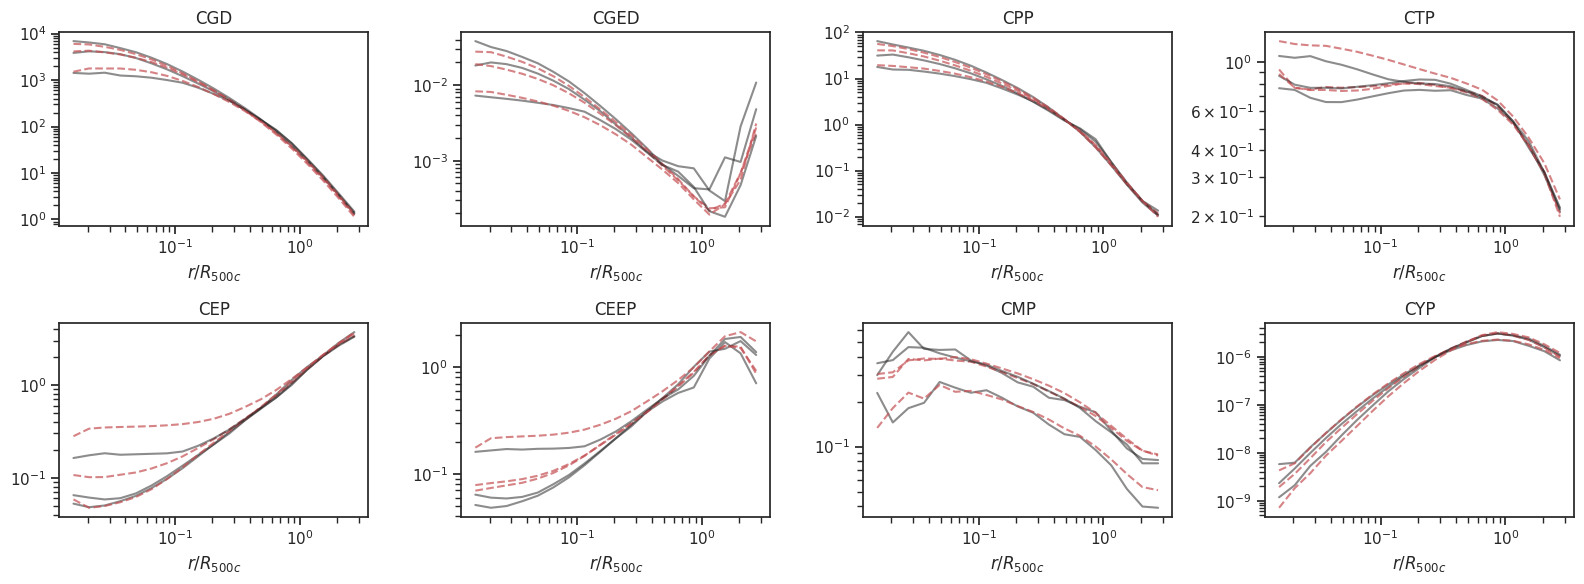

In [8]:
n_profiles = len(PROFILE_CONFIGS)
ncols = 4
nrows = (n_profiles + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for idx, (short_name, config) in enumerate(PROFILE_CONFIGS.items()):
    ax = axes[idx]
    model_list, data_list = profile_models[short_name]
    arr = profile_data[short_name]
    y_vals = arr[:, :, rad_cond]

    for t_idx in test_sim_indices[:3]:
        target = y_vals[t_idx, -1, :]  # z=0 (last snapshot)
        pred_mean, pred_quant = emulate(model_list[-1], params32[t_idx])
        ax.plot(y_ind_profiles, target, 'k-', alpha=0.5)
        ax.plot(y_ind_profiles, pred_mean[:, 0], 'r--', alpha=0.7)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(short_name)
    ax.set_xlabel(r'$r/R_{500c}$')

for idx in range(len(PROFILE_CONFIGS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/profiles_multiz_validation.png', bbox_inches='tight')

## Redshift interpolation test

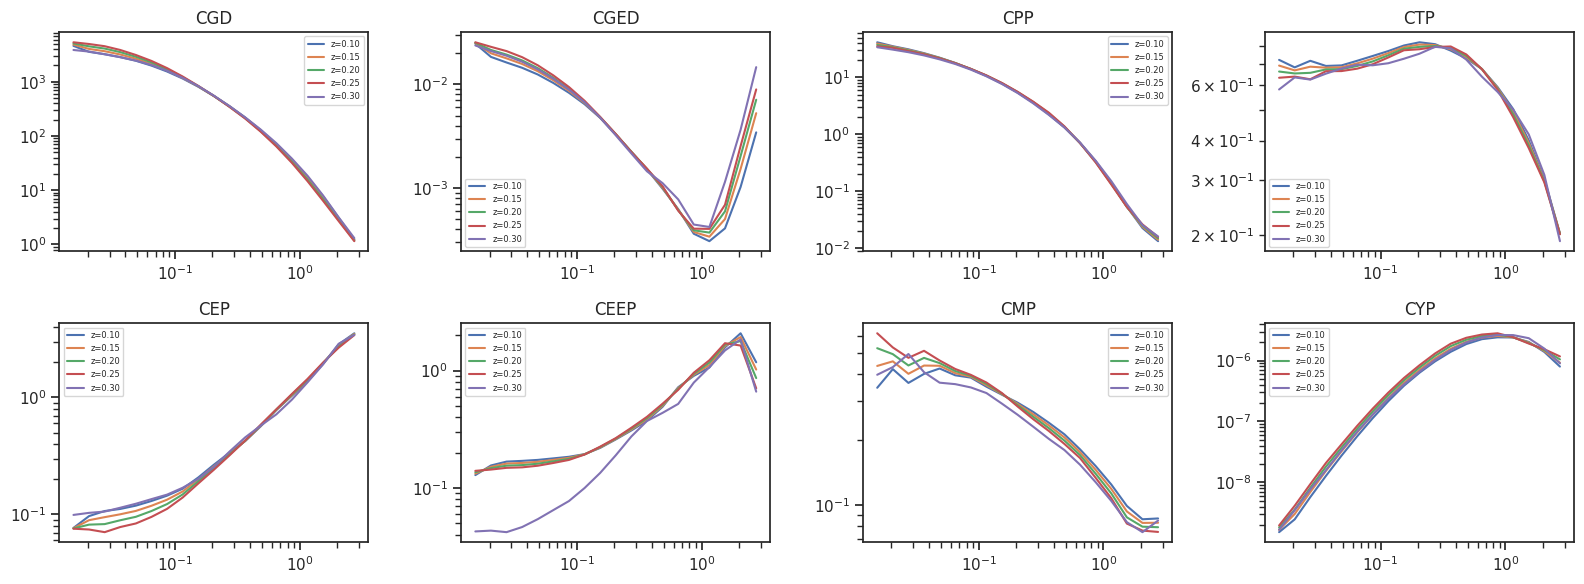

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

test_params = params32[test_sim_indices[0]]
z_grid = np.linspace(profile_z_all[-2], profile_z_all[1], 5)

for idx, (short_name, config) in enumerate(PROFILE_CONFIGS.items()):
    ax = axes[idx]
    model_list, data_list = profile_models[short_name]

    for z_target in z_grid:
        params_with_z = np.append(test_params, [z_target])[np.newaxis, :]
        pred_z, pred_z_err = emu_redshift(params_with_z, model_list, data_list, profile_z_all)
        ax.plot(y_ind_profiles, pred_z[:, 0], label=f'z={z_target:.2f}')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(short_name)
    ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig('../plots/profiles_multiz_redshift_interp.png', bbox_inches='tight')